# Imports

In [1]:
import numpy as np
import pandas as pd
import glob
import os

import cv2
import tensorflow as tf
import tfimm
import timm
from builtins import range, input
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Hyperparameters
epochs = 20
batch_size = 32

# Data Loading and FC Matrix Computation

In [3]:
# Compute Pearson Correlation Matrix

def compute_fc_matrix(filepath):
    # Each .1D file: rows = timepoints, columns = ROIs
    timeseries = np.loadtxt(filepath)  # shape: (T, n_rois)
    fc_matrix = np.corrcoef(timeseries.T)  # transpose so corrcoef treats ROIs as variables
    return fc_matrix

# Example: process every downloaded file
filepaths = glob.glob('./data/abide_aal_data/Outputs/cpac/filt_global/rois_cc200/*.1D')  # adjust path/pattern to match your download
fc_matrices = {}

for fp in filepaths:
    file_id = os.path.basename(fp).replace('_rois_cc200.1D', '')  # strip suffix to get FILE_ID
    fc_matrices[file_id] = compute_fc_matrix(fp)

print(f"Processed {len(fc_matrices)} subjects")
print(f"Matrix shape: {next(iter(fc_matrices.values())).shape}")  # should be (200, 200) for CC200

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processed 884 subjects
Matrix shape: (200, 200)


In [4]:
# Count the number of subjects that have 0 standard deviation

nan_counts = {}
for file_id, matrix in fc_matrices.items():
    n_nan = np.isnan(matrix).sum()
    if n_nan > 0:
        nan_counts[file_id] = n_nan

print(f"{len(nan_counts)} of {len(fc_matrices)} subjects have NaNs")
if nan_counts:
    # show the worst few
    worst = sorted(nan_counts.items(), key=lambda x: -x[1])[:5]
    print("Worst offenders:", worst)

35 of 884 subjects have NaNs
Worst offenders: [('Caltech_0051478', 33276), ('Caltech_0051469', 25600), ('SDSU_0050209', 10071), ('SDSU_0050216', 6144), ('Caltech_0051471', 5404)]


In [5]:
# Remove NaN subjects from the dictionary of matrices

fc_matrices_clean = {fid: mat for fid, mat in fc_matrices.items() if not np.isnan(mat).any()}
print(f"Kept {len(fc_matrices_clean)} of {len(fc_matrices)} subjects")

Kept 849 of 884 subjects


# Phenotypic Label Merge

In [6]:
# Merge subject data with phenotypic labels

pheno = pd.read_csv('./data/Phenotypic_V1_0b_preprocessed1.csv')

# Build labels lookup
labels = pheno[['FILE_ID', 'DX_GROUP']].copy()
labels = labels[labels['FILE_ID'] != 'no_filename']

# Merge with your CLEAN matrices
matched_data = []
for file_id, matrix in fc_matrices_clean.items():
    row = labels[labels['FILE_ID'] == file_id]
    if not row.empty:
        dx = row['DX_GROUP'].values[0]
        matched_data.append((file_id, matrix, dx))

print(f"Matched {len(matched_data)} of {len(fc_matrices_clean)} subjects to labels")
print(matched_data)

Matched 849 of 849 subjects to labels
[('Caltech_0051459', array([[ 1.        , -0.1773661 , -0.00602314, ..., -0.28906846,
        -0.34674923,  0.00569531],
       [-0.1773661 ,  1.        ,  0.23651303, ...,  0.17127448,
        -0.06847432, -0.31333132],
       [-0.00602314,  0.23651303,  1.        , ..., -0.07478013,
        -0.01658607, -0.04234176],
       ...,
       [-0.28906846,  0.17127448, -0.07478013, ...,  1.        ,
         0.03017183, -0.22089793],
       [-0.34674923, -0.06847432, -0.01658607, ...,  0.03017183,
         1.        , -0.17733803],
       [ 0.00569531, -0.31333132, -0.04234176, ..., -0.22089793,
        -0.17733803,  1.        ]]), 1), ('Caltech_0051461', array([[ 1.        , -0.23663444, -0.22839338, ...,  0.32799874,
         0.13613338,  0.0465256 ],
       [-0.23663444,  1.        ,  0.46683256, ...,  0.01660224,
        -0.07951879, -0.301523  ],
       [-0.22839338,  0.46683256,  1.        , ..., -0.00145756,
         0.11205156, -0.58666855],
   

In [7]:
import collections
labels_only = [dx for (_, _, dx) in matched_data]
print(collections.Counter(labels_only))

Counter({2: 458, 1: 391})


In [8]:
# Separate matrices by diagnosis group

ASD_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 1]
TDC_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 2]

print(f"ASD subjects: {len(ASD_matrices)}")
print(f"TDC subjects: {len(TDC_matrices)}")

ASD subjects: 391
TDC subjects: 458


# Preprocessing and Normalization

In [9]:
# Build X and y arrays from matched_data
X = np.array([mat for (_, mat, _) in matched_data])  # shape: (849, 200, 200)
y = np.array([dx for (_, _, dx) in matched_data])    # shape: (849,)

# Normalize: map correlation values from [-1, 1] to [0, 1]
X = (X + 1) / 2

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X min: {X.min():.4f}, X max: {X.max():.4f}")  # should be ~0.0 to ~1.0

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

print(collections.Counter(y))  # should show {0: 458, 1: 391}

X shape: (849, 200, 200)
y shape: (849,)
X min: 0.0204, X max: 1.0000
Counter({0: 458, 1: 391})


# Train Val Test Split

In [10]:
from sklearn.model_selection import train_test_split

# First split: train (70%) vs. temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=19
)

# Second split: val (15%) vs. test (15%) from the temp 30%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=19
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train labels: {collections.Counter(y_train)}")
print(f"Val labels:   {collections.Counter(y_val)}")
print(f"Test labels:  {collections.Counter(y_test)}")

Train: 594, Val: 127, Test: 128
Train labels: Counter({0: 320, 1: 274})
Val labels:   Counter({0: 69, 1: 58})
Test labels:  Counter({0: 69, 1: 59})


# Model Definition ----------------

**Reshape Data**

In [49]:
import tensorflow as tf
from keras.layers import Input

# Resize and tile X arrays to match pretrained backbone expectations
# Commented out the below 3 lines (Change A)
X_train_model = tf.image.resize(X_train[..., np.newaxis], [224, 224]).numpy()
X_val_model   = tf.image.resize(X_val[..., np.newaxis],   [224, 224]).numpy()
X_test_model  = tf.image.resize(X_test[..., np.newaxis],  [224, 224]).numpy()
# Replaced below 3 with above 3 (Original i think)
# Tile single channel to 3 channels (pretrained models expect RGB-like input)
X_train_model = np.repeat(X_train_model, 3, axis=-1)
X_val_model   = np.repeat(X_val_model,   3, axis=-1)
X_test_model  = np.repeat(X_test_model,  3, axis=-1)

# Input shape variable used by all three models
cnn_inp_y = Input(shape=(224, 224, 3)) # Changed from (224, 224, 3) to (200, 200, 3) (Change A)
inp_y = Input(shape=(224, 224, 3)) # Added for ViT model (Change C)

print(f"X_train_model shape: {X_train_model.shape}")  # should be (594, 224, 224, 3)
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (594, 224, 224, 3)
X_val_model shape:   (127, 224, 224, 3)
X_test_model shape:  (128, 224, 224, 3)


**CNN (ResNet)**

In [63]:
base_model_cnn = tfimm.create_model("resnet18", pretrained="timm", nb_classes=0)

for layer_cnn in base_model_cnn.layers:
    layer_cnn.trainable = False # Changed from False to True
out_cnn = base_model_cnn(inp_y)

out_cnn = Dense(64, activation='relu')(out_cnn)
out_cnn = Dropout(0.5)(out_cnn)
output = Dense(2, activation='softmax')(out_cnn)

model_cnn = Model(inputs=[inp_y], outputs=output)
model_cnn.summary()

All PyTorch model weights were used when initializing ResNet.
All the weights of ResNet were initialized from the PyTorch model.



Model: "model_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 resnet18 (ResNet)           (None, 512)               11186112  
                                                                 
 dense_30 (Dense)            (None, 64)                32832     
                                                                 
 dropout_1224 (Dropout)      (None, 64)                0         
                                                                 
 dense_31 (Dense)            (None, 2)                 130       
                                                                 
Total params: 11219074 (42.80 MB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 11186112 (42.67 MB)
_________________________________________________________________


In [64]:
print("model_cnn.output_shape: ", model_cnn.output_shape)

print("y_train.shape: ", y_train.shape)
print("y_val.shape: ", y_val.shape)

print("y_train[:5]: ", y_train[:5])

model_cnn.output_shape:  (None, 2)
y_train.shape:  (594,)
y_val.shape:  (127,)
y_train[:5]:  [0 0 0 0 1]


**ViT**

In [65]:
base_model_vit = tfimm.create_model("vit_tiny_patch16_224", pretrained="timm", nb_classes=0)

for layer_vit in base_model_vit.layers:
    layer_vit.trainable = False # Changed from False to True
out_vit = base_model_vit(inp_y)
out_vit = Flatten()(out_vit)

output = Dense(2, activation='softmax')(out_vit)
model_vit = Model(inputs=[inp_y], outputs=output)
model_vit.summary()

All PyTorch model weights were used when initializing ViT.
All the weights of ViT were initialized from the PyTorch model.



Model: "model_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 vit_tiny_patch16_224 (ViT)  (None, 192)               5524416   
                                                                 
 flatten_32 (Flatten)        (None, 192)               0         
                                                                 
 dense_32 (Dense)            (None, 2)                 386       
                                                                 
Total params: 5524802 (21.08 MB)
Trainable params: 38402 (150.01 KB)
Non-trainable params: 5486400 (20.93 MB)
_________________________________________________________________


**Pyramid ViT**

In [85]:
base_model_pvt = tfimm.create_model("pvt_tiny", pretrained="timm", nb_classes=0)

for layer_pvt in base_model_pvt.layers:
    layer_pvt.trainable = False # Changed from False to True
out_pvt = base_model_pvt(inp_y)
out_pvt = Flatten()(out_pvt)

output = Dense(2, activation='softmax')(out_pvt)
model_pvt = Model(inputs=[inp_y], outputs=output)
model_pvt.summary()

All PyTorch model weights were used when initializing PyramidVisionTransformer.
All the weights of PyramidVisionTransformer were initialized from the PyTorch model.



Model: "model_27"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 pvt_tiny (PyramidVisionTra  (None, 512)               12716288  
 nsformer)                                                       
                                                                 
 flatten_36 (Flatten)        (None, 512)               0         
                                                                 
 dense_36 (Dense)            (None, 2)                 1026      
                                                                 
Total params: 12717314 (48.51 MB)
Trainable params: 390914 (1.49 MB)
Non-trainable params: 12326400 (47.02 MB)
_________________________________________________________________


# Training ------------

In [67]:
opt_model_cnn = Adam(learning_rate=0.001)

model_cnn.compile(optimizer=opt_model_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Training:")
history_model_cnn = model_cnn.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

CNN Training:
Epoch 1/20
19/19 [==============================] - 6s 260ms/step - loss: 0.7271 - accuracy: 0.5152 - val_loss: 0.6967 - val_accuracy: 0.4646
Epoch 2/20
19/19 [==============================] - 5s 251ms/step - loss: 0.7179 - accuracy: 0.5051 - val_loss: 0.6898 - val_accuracy: 0.5906
Epoch 3/20
19/19 [==============================] - 5s 272ms/step - loss: 0.6947 - accuracy: 0.5522 - val_loss: 0.6938 - val_accuracy: 0.5433
Epoch 4/20
19/19 [==============================] - 5s 255ms/step - loss: 0.6933 - accuracy: 0.5320 - val_loss: 0.6938 - val_accuracy: 0.4646
Epoch 5/20
19/19 [==============================] - 4s 229ms/step - loss: 0.6859 - accuracy: 0.5404 - val_loss: 0.6890 - val_accuracy: 0.5433
Epoch 6/20
19/19 [==============================] - 4s 238ms/step - loss: 0.6794 - accuracy: 0.5657 - val_loss: 0.6877 - val_accuracy: 0.5433
Epoch 7/20
19/19 [==============================] - 4s 235ms/step - loss: 0.6755 - accuracy: 0.5758 - val_loss: 0.6861 - val_accuracy:

In [68]:
opt_model_vit = Adam(learning_rate=0.001)

model_vit.compile(optimizer=opt_model_vit, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Standard ViT Training:")
history_model_vit = model_vit.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Standard ViT Training:
Epoch 1/20
19/19 [==============================] - 28s 1s/step - loss: 0.8661 - accuracy: 0.5455 - val_loss: 0.8473 - val_accuracy: 0.5433
Epoch 2/20
19/19 [==============================] - 18s 962ms/step - loss: 0.6531 - accuracy: 0.6498 - val_loss: 0.7581 - val_accuracy: 0.5039
Epoch 3/20
19/19 [==============================] - 18s 967ms/step - loss: 0.5348 - accuracy: 0.7475 - val_loss: 0.7603 - val_accuracy: 0.5748
Epoch 4/20
19/19 [==============================] - 18s 967ms/step - loss: 0.4548 - accuracy: 0.7980 - val_loss: 0.7394 - val_accuracy: 0.5591
Epoch 5/20
19/19 [==============================] - 18s 970ms/step - loss: 0.3902 - accuracy: 0.8384 - val_loss: 0.7589 - val_accuracy: 0.5984
Epoch 6/20
19/19 [==============================] - 18s 946ms/step - loss: 0.3139 - accuracy: 0.9007 - val_loss: 0.7610 - val_accuracy: 0.5354
Epoch 7/20
19/19 [==============================] - 18s 956ms/step - loss: 0.2598 - accuracy: 0.9226 - val_loss: 0.7769 - 

In [ ]:
opt_model_pvt = Adam(learning_rate=0.001)

model_pvt.compile(optimizer=opt_model_pvt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pyramid ViT Training:")
history_model_pvt = model_pvt.fit(x=X_train_model, y=y_train, epochs=epochs, batch_size=batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Pyramid ViT Training:
Epoch 1/20
19/19 [==============================] - 49s 2s/step - loss: 1.1038e-08 - accuracy: 1.0000 - val_loss: 3.1255 - val_accuracy: 0.5748
Epoch 2/20
19/19 [==============================] - 42s 2s/step - loss: 2.6090e-09 - accuracy: 1.0000 - val_loss: 3.2319 - val_accuracy: 0.5591
Epoch 3/20
19/19 [==============================] - 42s 2s/step - loss: 8.0276e-10 - accuracy: 1.0000 - val_loss: 3.2976 - val_accuracy: 0.5669
Epoch 4/20
19/19 [==============================] - 41s 2s/step - loss: 2.0069e-10 - accuracy: 1.0000 - val_loss: 3.3473 - val_accuracy: 0.5591
Epoch 5/20
19/19 [==============================] - 41s 2s/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 3.3894 - val_accuracy: 0.5512
Epoch 6/20
19/19 [==============================] - 41s 2s/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 3.4211 - val_accuracy: 0.5512
Epoch 7/20
19/19 [==============================] - 39s 2s/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 

# Evaluation and Results

### CNN

**Results**

In [70]:
y_pred_cnn = model_cnn.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_cnn = np.argmax(y_pred_cnn, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_cnn)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_cnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (ResNet-18):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 1s 190ms/step
Results for Across Y - (ResNet-18):
tp: 65
tn: 8
fp: 51
fn: 4
Accuracy:  0.5703125
Sensitivity:  0.9420289855072463
Specificity:  0.13559322033898305
Precision:  0.5603448275862069
F1 Score: 0.7027027027027027
AUC: 0.5388111029231147


**Plots**

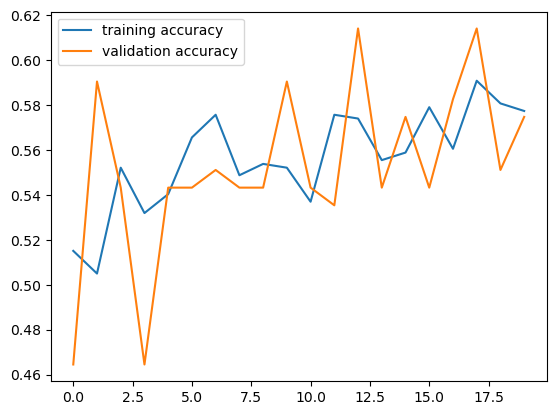

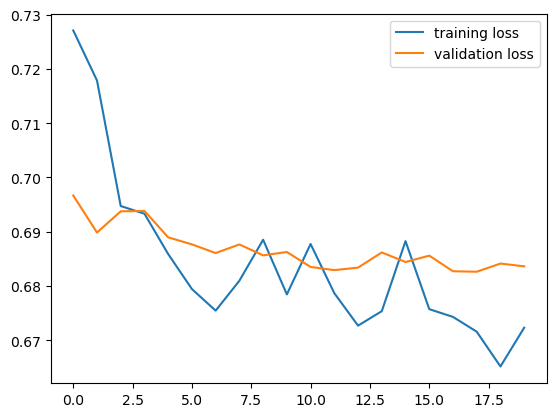

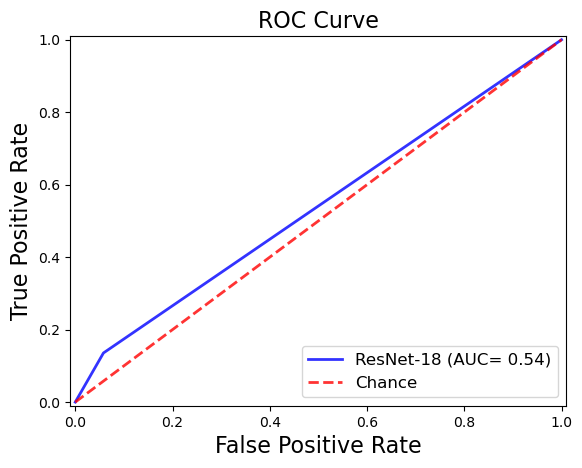

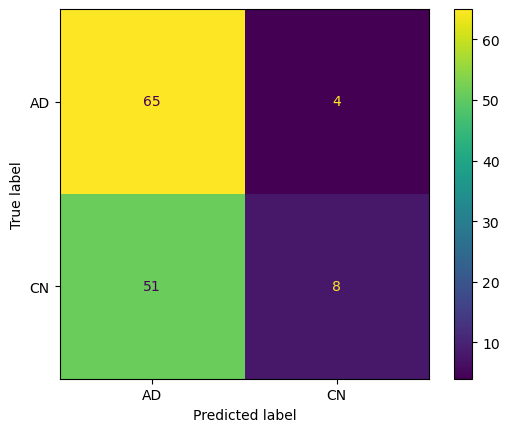

In [71]:
### Training, validation, and testing plot
plt.plot(history_model_cnn.history["accuracy"], label="training accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_cnn.history["loss"], label="training loss")
plt.plot(history_model_cnn.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ResNet-18 (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

### ViT

**Results**

In [ ]:
y_pred_vit = model_vit.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_vit = np.argmax(y_pred_vit, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_vit)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_vit).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Standard ViT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 2s 291ms/step
Results for Across Y - (Standard ViT):
tp: 43
tn: 33
fp: 26
fn: 26
Accuracy:  0.59375
Sensitivity:  0.6231884057971014
Specificity:  0.559322033898305
Precision:  0.6231884057971014
F1 Score: 0.6231884057971014
AUC: 0.5912552198477032


**Plots**

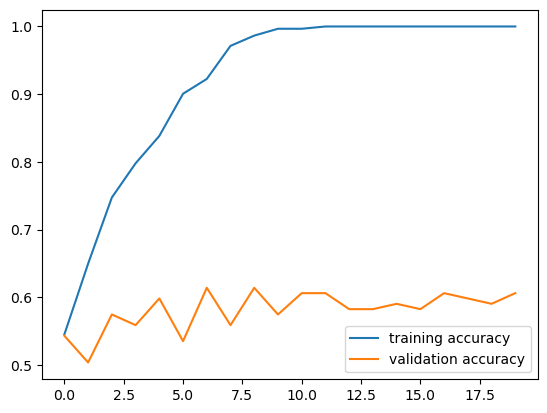

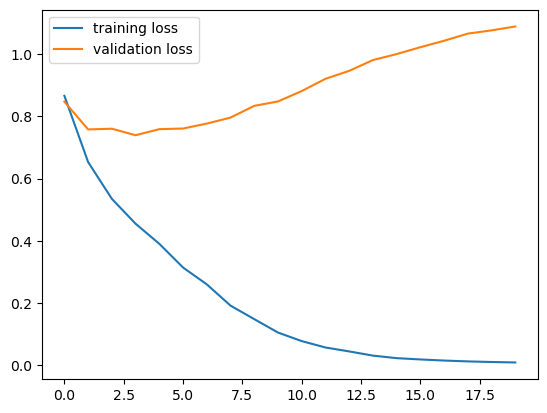

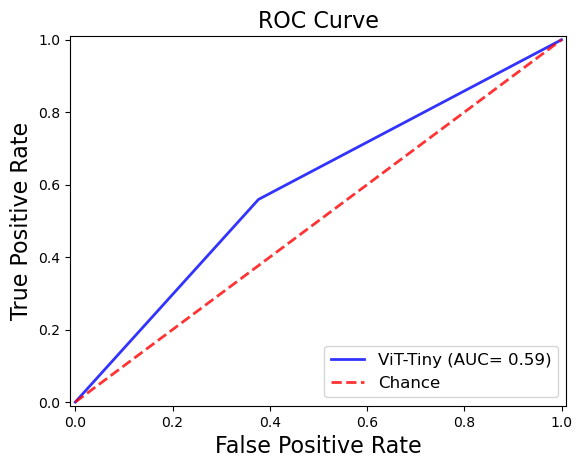

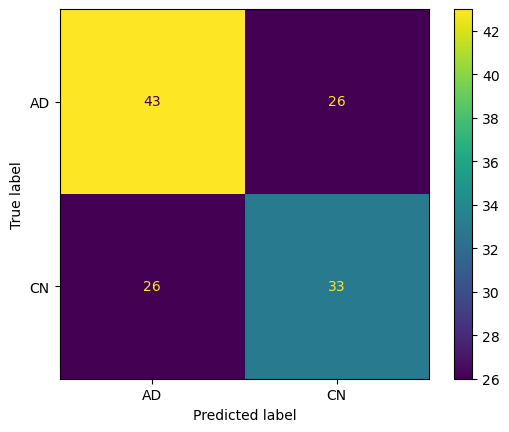

In [73]:
### Training, validation, and testing plot
plt.plot(history_model_vit.history["accuracy"], label="training accuracy")
plt.plot(history_model_vit.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_vit.history["loss"], label="training loss")
plt.plot(history_model_vit.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ViT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

### Pyramid ViT

**Results**

In [94]:
y_pred_pvt = model_pvt.predict(X_test_model, batch_size=batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_pvt = np.argmax(y_pred_pvt, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_pvt)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_pvt).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Pyramid ViT-Tiny):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 4s 779ms/step
Results for Across Y - (Pyramid ViT-Tiny):
tp: 43
tn: 34
fp: 25
fn: 26
Accuracy:  0.6015625
Sensitivity:  0.6231884057971014
Specificity:  0.576271186440678
Precision:  0.6323529411764706
F1 Score: 0.6277372262773723
AUC: 0.5997297961188897


**Plots**

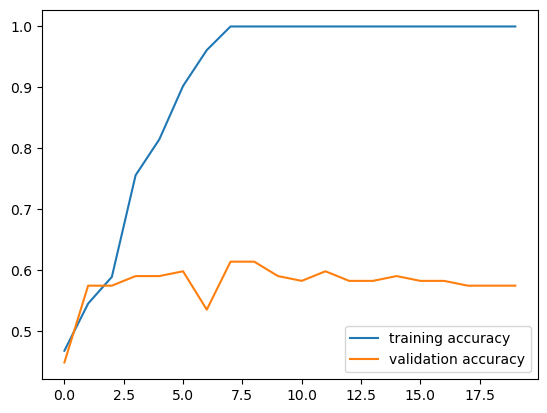

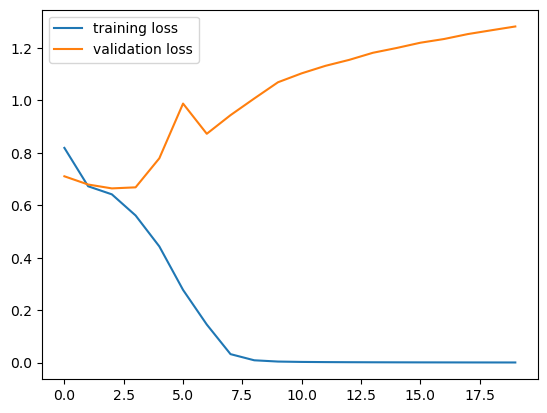

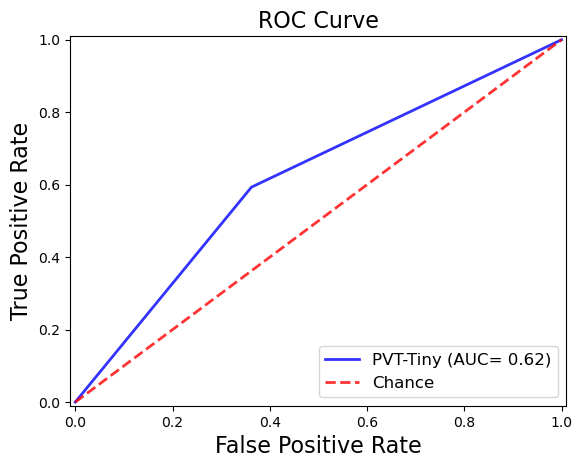

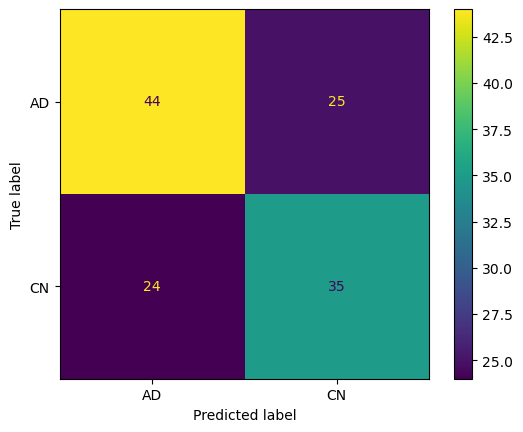

In [88]:
### Training, validation, and testing plot
plt.plot(history_model_pvt.history["accuracy"], label="training accuracy")
plt.plot(history_model_pvt.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_pvt.history["loss"], label="training loss")
plt.plot(history_model_pvt.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'PVT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_pvt)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()